In [18]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
from joblib import dump, load                                                           # type: ignore

### Importing dataset

In [19]:
raw_train_data = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/cleaned/train-data-Bamako.csv", index_col=False)
raw_test_data = pd.read_csv("/home/mendrika/mendrika-phd/data/other-location/cleaned/test-data-Bamako.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [20]:
raw_test_data = raw_test_data.dropna()
raw_train_data = raw_train_data.dropna()

#### Choosing field to include in the data

In [21]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features.split(',')

### Exploratory data analysis

In [22]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [23]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [24]:
to_scale = wavelet_power + storm_size + distance

In [25]:
transform = True
if transform:    
    transformed_test_data = log_transform(raw_test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(transformed_test_data, t0.split(',')[:-1])
    transformed_train_data = log_transform(raw_train_data, to_scale.split(',')[:-1])    
    train_data_original = sqrt_transform(transformed_train_data, t0.split(',')[:-1])

In [26]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [27]:
raw_test_data[raw_test_data["hour"] == 18]

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_bamako_t1,Cb_bamako_t2,Cb_bamako_t3
5,2020,6,1,18,0,10.29,-3.51,11.37,-1.89,12.67,...,14650.0,0.0,153.84,179.36,215.01,222.60,500.00,0.0,0.0,0.0
6,2020,6,1,18,15,11.73,-1.17,10.33,-3.60,11.10,...,11275.0,0.0,176.24,214.00,221.68,246.09,500.00,0.0,0.0,0.0
7,2020,6,1,18,30,11.82,-1.22,10.42,-3.73,12.58,...,9025.0,0.0,170.42,209.01,219.27,244.72,500.00,0.0,0.0,0.0
8,2020,6,1,18,45,11.86,-1.31,10.51,-3.82,11.05,...,10250.0,1525.0,165.92,206.02,215.41,240.52,306.81,0.0,0.0,0.0
80,2020,6,4,18,0,12.94,-3.55,14.42,-1.40,12.26,...,2800.0,0.0,159.38,212.46,240.35,245.23,500.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17376,2022,9,25,18,45,12.49,-5.66,10.83,-6.74,17.47,...,7425.0,3175.0,53.26,77.94,83.15,123.00,177.09,0.0,0.0,0.0
17469,2022,9,26,18,0,12.31,-7.10,14.42,-5.39,10.87,...,5100.0,26450.0,33.24,36.06,45.71,63.13,113.16,1.0,0.0,0.0
17470,2022,9,26,18,15,13.70,-5.93,13.07,-7.23,13.52,...,23400.0,23400.0,30.87,30.89,63.01,82.73,99.93,1.0,0.0,0.0
17471,2022,9,26,18,30,14.24,-8.54,12.26,-7.32,11.01,...,11825.0,5500.0,26.42,43.42,57.80,58.14,58.52,1.0,0.0,0.0


In [28]:
train_data, _ = train_test_split(train_data_original, test_size=0.2, random_state=12)

In [29]:
y_test_t1 = test_data["Cb_bamako_t1"].to_numpy()
y_test_t3 = test_data["Cb_bamako_t3"].to_numpy()
y_test_t6 = test_data["Cb_bamako_t2"].to_numpy()

In [30]:
y_train_t1 = train_data["Cb_bamako_t1"].to_numpy()
y_train_t3 = train_data["Cb_bamako_t3"].to_numpy()
y_train_t6 = train_data["Cb_bamako_t2"].to_numpy()

In [31]:
x_test = test_data.drop(["Cb_bamako_t1", "Cb_bamako_t3", "Cb_bamako_t2"], axis=1)
x_train = train_data.drop(["Cb_bamako_t1", "Cb_bamako_t3", "Cb_bamako_t2"], axis=1)

In [32]:
model_t1 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Bamako-t1.keras")
model_t3 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Bamako-t3.keras")
model_t6 = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Bamako-t2.keras")

In [33]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/scaler-Bamako.bin')

In [34]:
x_test_std = scaler.transform(x_test)
x_train_std = scaler.transform(x_train)

In [35]:
def class_prediction(model, x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [36]:
def plot_cm(y, y_hat, classification_threshold):     
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

### Performance on testing data

In [37]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

In [38]:
y_train_pred_t1, auc_train_t1, bs_train_t1 = class_prediction(model_t1, x_train_std, y_train_t1)
y_train_pred_t3, auc_train_t3, bs_train_t3 = class_prediction(model_t3, x_train_std, y_train_t3)
y_train_pred_t6, auc_train_t6, bs_train_t6 = class_prediction(model_t6, x_train_std, y_train_t6)

2212/2212 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2212/2212 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
2212/2212 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [39]:
y_test_pred_t1, auc_test_t1, bs_test_t1 = class_prediction(model_t1, x_test_std, y_test_t1)
y_test_pred_t3, auc_test_t3, bs_test_t3 = class_prediction(model_t3, x_test_std, y_test_t3)
y_test_pred_t6, auc_test_t6, bs_test_t6 = class_prediction(model_t6, x_test_std, y_test_t6)

549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
549/549 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [40]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

In [41]:
prob_pred_t1, prob_true_t1, no_pred_per_bin_t1 = reliability_curve(y_test_t1, y_test_pred_t1.flatten())
prob_pred_t3, prob_true_t3, no_pred_per_bin_t3 = reliability_curve(y_test_t3, y_test_pred_t3.flatten())
prob_pred_t6, prob_true_t6, no_pred_per_bin_t6 = reliability_curve(y_test_t6, y_test_pred_t6.flatten())

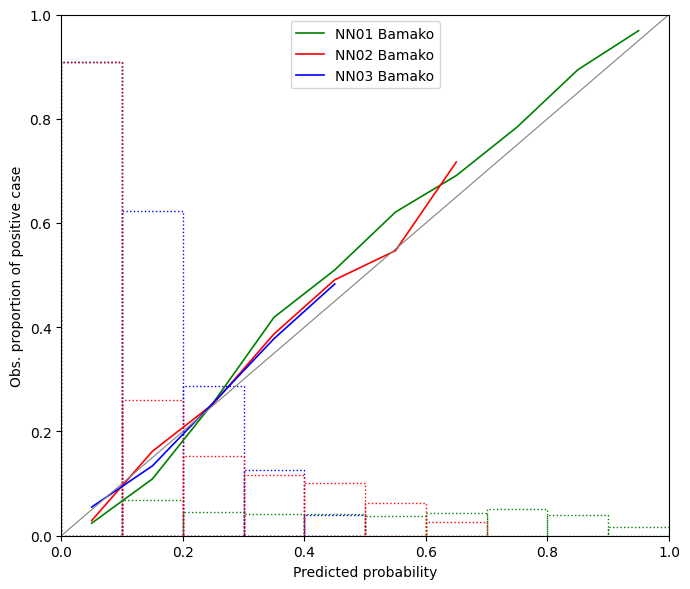

In [47]:
plt.figure(figsize=(7, 6))

plt.plot(prob_pred_t1, prob_true_t1, label=f"NN01 Bamako", color="green", linewidth=1.2)    
plt.plot(prob_pred_t6, prob_true_t6, label=f"NN02 Bamako", color="red", linewidth=1.2)
plt.plot(prob_pred_t3, prob_true_t3, label=f"NN03 Bamako", color="blue", linewidth=1.2)


no_pred_per_bin_t1 = [i/(1.1*np.max(no_pred_per_bin_t1)) for i in no_pred_per_bin_t1]
no_pred_per_bin_t3 = [i/(1.1*np.max(no_pred_per_bin_t3)) for i in no_pred_per_bin_t3]
no_pred_per_bin_t6 = [i/(1.1*np.max(no_pred_per_bin_t6)) for i in no_pred_per_bin_t6]


plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2), color="gray", linewidth=0.8)
plt.bar(prob_pred_t1, no_pred_per_bin_t1, width=0.1, linestyle=":", fill=False, edgecolor="green")
plt.bar(prob_pred_t3, no_pred_per_bin_t3, width=0.1, linestyle=":", fill=False, edgecolor="blue")
plt.bar(prob_pred_t6, no_pred_per_bin_t6, width=0.1, linestyle=":", fill=False, edgecolor="red")


plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")
plt.legend(loc='upper center')
plt.tight_layout()
plt.show()

In [43]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)  
  plt.plot(100*fp, 100*tp, label=name, linewidth=1.2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,101])
  plt.ylim([0,101])
  plt.grid(True, linewidth=0.3)
  ax = plt.gca()
  ax.set_aspect('equal')
  plt.tight_layout()

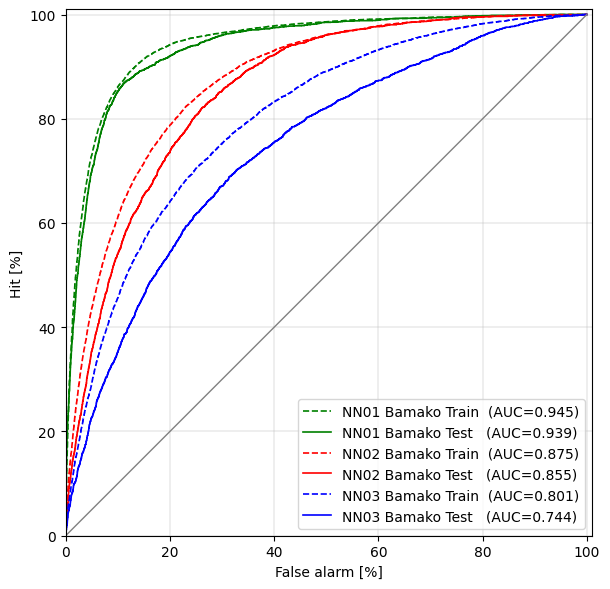

In [48]:
mpl.rcParams['figure.figsize'] = (7,6)


plot_roc(f"NN01 Bamako Train  (AUC={auc_train_t1:.3f})", y_train_t1, y_train_pred_t1, color="green", linestyle="--")
plot_roc(f"NN01 Bamako Test   (AUC={auc_test_t1:.3f})", y_test_t1, y_test_pred_t1, color="green")

plot_roc(f"NN02 Bamako Train  (AUC={auc_train_t6:.3f})", y_train_t6, y_train_pred_t6, color="red", linestyle="--")
plot_roc(f"NN02 Bamako Test   (AUC={auc_test_t6:.3f})", y_test_t6, y_test_pred_t6, color="red")


plot_roc(f"NN03 Bamako Train  (AUC={auc_train_t3:.3f})", y_train_t3, y_train_pred_t3, color="blue", linestyle="--")
plot_roc(f"NN03 Bamako Test   (AUC={auc_test_t3:.3f})", y_test_t3, y_test_pred_t3, color="blue")


plt.plot(np.arange(0,1.2,0.2)*100, np.arange(0,1.2,0.2)*100, color="gray", linewidth=1)

plt.legend(loc='lower right');

In [45]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')